# 📊 Customer Segmentation Analysis
### Full Pipeline: Data Cleaning → EDA → Feature Engineering → Predictive Modelling → Visualization

**Dataset:** `CustSegmentation_Tableau_input_.csv`  
**Rows:** ~878K transactions | **Customers:** 4,010 accounts | **Clusters:** 10 pre-assigned segments

---

## 0️⃣ Install & Import Libraries

In [1]:
# Install any missing libraries
!pip install scikit-learn xgboost imbalanced-learn yellowbrick --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    ConfusionMatrixDisplay, silhouette_score
)
from xgboost import XGBClassifier

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
PALETTE = 'tab10'
print('✅ All libraries loaded successfully.')

✅ All libraries loaded successfully.


---
## 1️⃣ Load Data

In [3]:
# -----------------------------------------------------------------
# If running in Google Colab, upload the CSV first:
#   from google.colab import files
#   uploaded = files.upload()
#   FILE_PATH = list(uploaded.keys())[0]
# -----------------------------------------------------------------
FILE_PATH = 'CustSegmentation_Tableau_input_.csv'   # ← adjust if needed

df_raw = pd.read_csv(FILE_PATH)
print(f'Shape: {df_raw.shape}')
df_raw.head()

Shape: (752671, 7)


,Unnamed: 0,Cluster,ProdCat1,ProdCat2,GROSS_TURNOVER,INVOICE_NUMBER,Main_account_name_number
0,0,3,Television and Entertainment,Music Streaming Services,364.6500,2,17566_Customer Group_1
1,1,3,Mobile Services,Mobile Plans (Prepaid),93820.4062,191,17566_Customer Group_1
2,2,3,Communication Tools,Virtual Event Hosting,11502.9356,13,17566_Customer Group_1
3,3,3,Television and Entertainment,Local TV Channels,61291.8434,21,17566_Customer Group_1
4,4,3,Gaming and eSports,Game Development Services,520.6140,1,17566_Customer Group_1


In [4]:
print('=== Data Types & Non-Null Counts ===')
df_raw.info()
print('\n=== Statistical Summary ===')
df_raw.describe(include='all')

=== Data Types & Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 752671 entries, 0 to 752670
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                752671 non-null  int64  
 1   Cluster                   752671 non-null  int64  
 2   ProdCat1                  752671 non-null  object 
 3   ProdCat2                  752671 non-null  object 
 4   GROSS_TURNOVER            752671 non-null  float64
 5   INVOICE_NUMBER            752671 non-null  int64  
 6   Main_account_name_number  752671 non-null  object 
dtypes: float64(1), int64(3), object(3)
memory usage: 40.2+ MB

=== Statistical Summary ===


,Unnamed: 0,Cluster,ProdCat1,ProdCat2,GROSS_TURNOVER,INVOICE_NUMBER,Main_account_name_number
count,752671.000000,752671.000000,752671,752671,7.526710e+05,752671.000000,752671
unique,NaN,NaN,21,219,NaN,NaN,3438
top,NaN,NaN,Television and Entertainment,Music Streaming Services,NaN,NaN,93713_Customer Group_1031
freq,NaN,NaN,58428,3437,NaN,NaN,219
mean,376335.000000,3.689705,NaN,NaN,1.223454e+03,0.682384,NaN
std,217277.546567,2.248365,NaN,NaN,2.535209e+04,6.378533,NaN
min,0.000000,0.000000,NaN,NaN,0.000000e+00,0.000000,NaN
25%,188167.500000,3.000000,NaN,NaN,0.000000e+00,0.000000,NaN
50%,376335.000000,3.000000,NaN,NaN,0.000000e+00,0.000000,NaN
75%,564502.500000,4.000000,NaN,NaN,0.000000e+00,0.000000,NaN


---
## 2️⃣ Data Cleaning & Manipulation

In [5]:
df = df_raw.copy()

# ── 2.1  Drop unnamed index column ──────────────────────────────
unnamed_cols = [c for c in df.columns if 'Unnamed' in c]
df.drop(columns=unnamed_cols, inplace=True)
print(f'Dropped {len(unnamed_cols)} unnamed column(s).')

# ── 2.2  Rename columns for clarity ─────────────────────────────
df.rename(columns={
    'Main_account_name_number': 'Account',
    'GROSS_TURNOVER':           'GrossTurnover',
    'INVOICE_NUMBER':           'InvoiceCount',
    'ProdCat1':                 'Category',
    'ProdCat2':                 'SubCategory',
    'Cluster':                  'Cluster'
}, inplace=True)

print('Columns after rename:', df.columns.tolist())

Dropped 1 unnamed column(s).
Columns after rename: ['Cluster', 'Category', 'SubCategory', 'GrossTurnover', 'InvoiceCount', 'Account']


In [6]:
# ── 2.3  Missing values ──────────────────────────────────────────
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values ✅')

Missing values per column:
No missing values ✅


In [7]:
# ── 2.4  Duplicates ──────────────────────────────────────────────
n_dups = df.duplicated().sum()
print(f'Duplicate rows: {n_dups}')
df.drop_duplicates(inplace=True)
print(f'Shape after dedup: {df.shape}')

Duplicate rows: 0
Shape after dedup: (752671, 6)


In [8]:
# ── 2.5  Outlier inspection (GrossTurnover) ──────────────────────
q1  = df['GrossTurnover'].quantile(0.25)
q3  = df['GrossTurnover'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 3 * iqr       # lenient cap to preserve large B2B deals

n_outliers = (df['GrossTurnover'] > upper_fence).sum()
print(f'Extreme outliers (> Q3+3×IQR = {upper_fence:,.0f}): {n_outliers:,} rows')

# Cap rather than drop — large B2B transactions are genuine
df['GrossTurnover_capped'] = df['GrossTurnover'].clip(upper=upper_fence)
print('Added GrossTurnover_capped column (winsorised).')

Extreme outliers (> Q3+3×IQR = 0): 90,802 rows
Added GrossTurnover_capped column (winsorised).


In [9]:
# ── 2.6  Flag zero-revenue rows ─────────────────────────────────
df['IsZeroRevenue'] = (df['GrossTurnover'] == 0).astype(int)
pct_zero = df['IsZeroRevenue'].mean() * 100
print(f'Zero-revenue rows: {df["IsZeroRevenue"].sum():,} ({pct_zero:.1f}% of dataset)')

Zero-revenue rows: 661,869 (87.9% of dataset)


In [10]:
# ── 2.7  Type enforcement ────────────────────────────────────────
df['Cluster']      = df['Cluster'].astype('category')
df['Category']     = df['Category'].astype('category')
df['SubCategory']  = df['SubCategory'].astype('category')

print('Final cleaned shape:', df.shape)
df.dtypes

Final cleaned shape: (752671, 8)


,0
Cluster,category
Category,category
SubCategory,category
GrossTurnover,float64
InvoiceCount,int64
Account,object
GrossTurnover_capped,float64
IsZeroRevenue,int64


---
## 3️⃣ Exploratory Data Analysis (EDA)

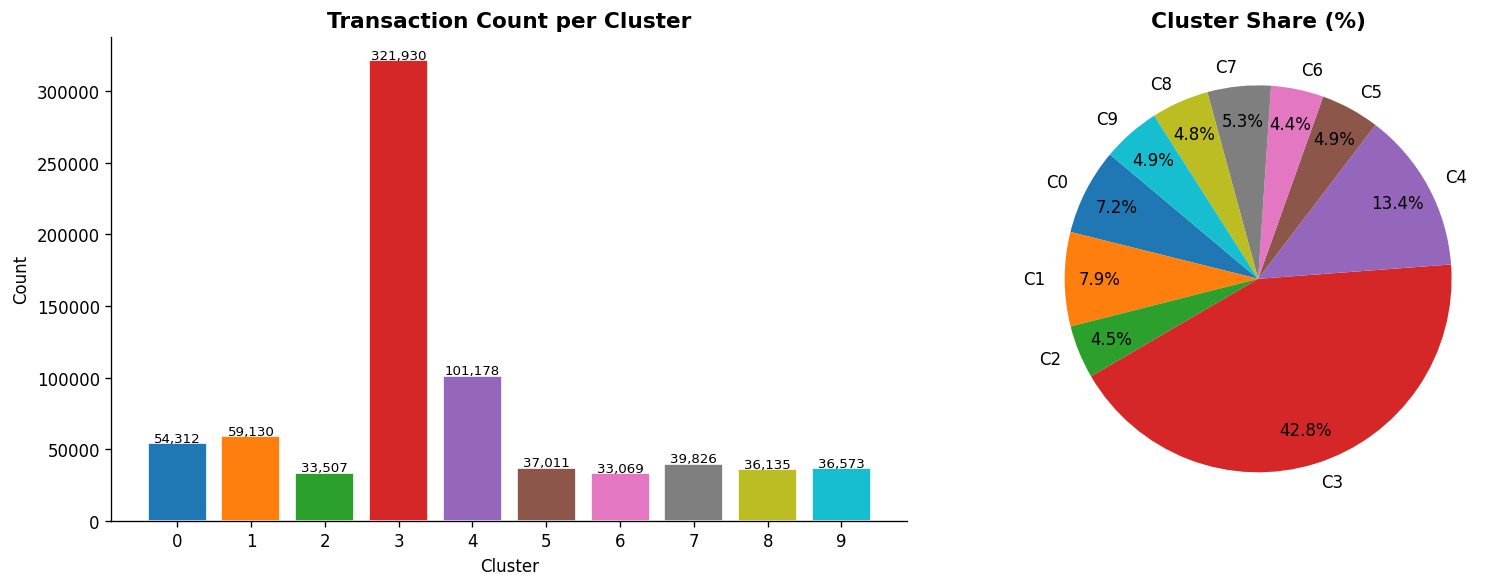

In [11]:
# ── 3.1  Cluster distribution ────────────────────────────────────
cluster_counts = df['Cluster'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar
colors = plt.cm.tab10(np.linspace(0, 1, len(cluster_counts)))
axes[0].bar(cluster_counts.index.astype(str), cluster_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Transaction Count per Cluster', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Count')
for i, v in enumerate(cluster_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=8)

# Pie
axes[1].pie(cluster_counts.values, labels=[f'C{c}' for c in cluster_counts.index],
            colors=colors, autopct='%1.1f%%', startangle=140, pctdistance=0.82)
axes[1].set_title('Cluster Share (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('cluster_distribution.png', bbox_inches='tight')
plt.show()

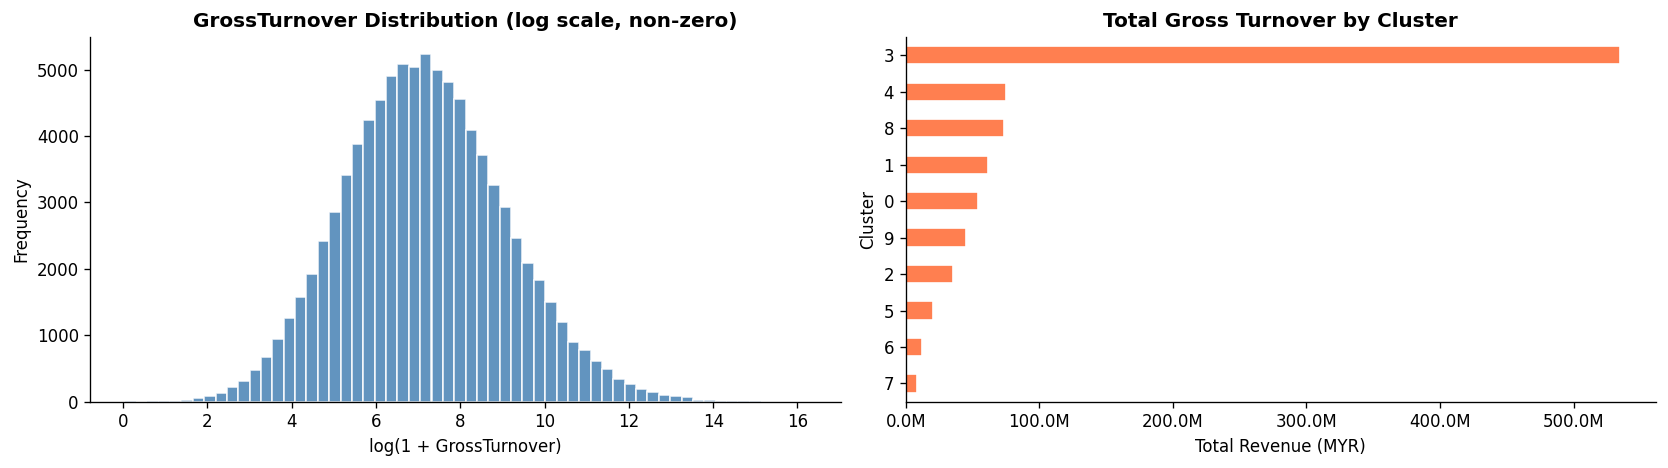

In [12]:
# ── 3.2  Gross Turnover distribution ────────────────────────────
nonzero = df[df['GrossTurnover'] > 0]['GrossTurnover']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(np.log1p(nonzero), bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('GrossTurnover Distribution (log scale, non-zero)', fontweight='bold')
axes[0].set_xlabel('log(1 + GrossTurnover)'); axes[0].set_ylabel('Frequency')

cluster_revenue = df.groupby('Cluster', observed=True)['GrossTurnover'].sum().sort_values(ascending=True)
cluster_revenue.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Total Gross Turnover by Cluster', fontweight='bold')
axes[1].set_xlabel('Total Revenue (MYR)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('turnover_distribution.png', bbox_inches='tight')
plt.show()

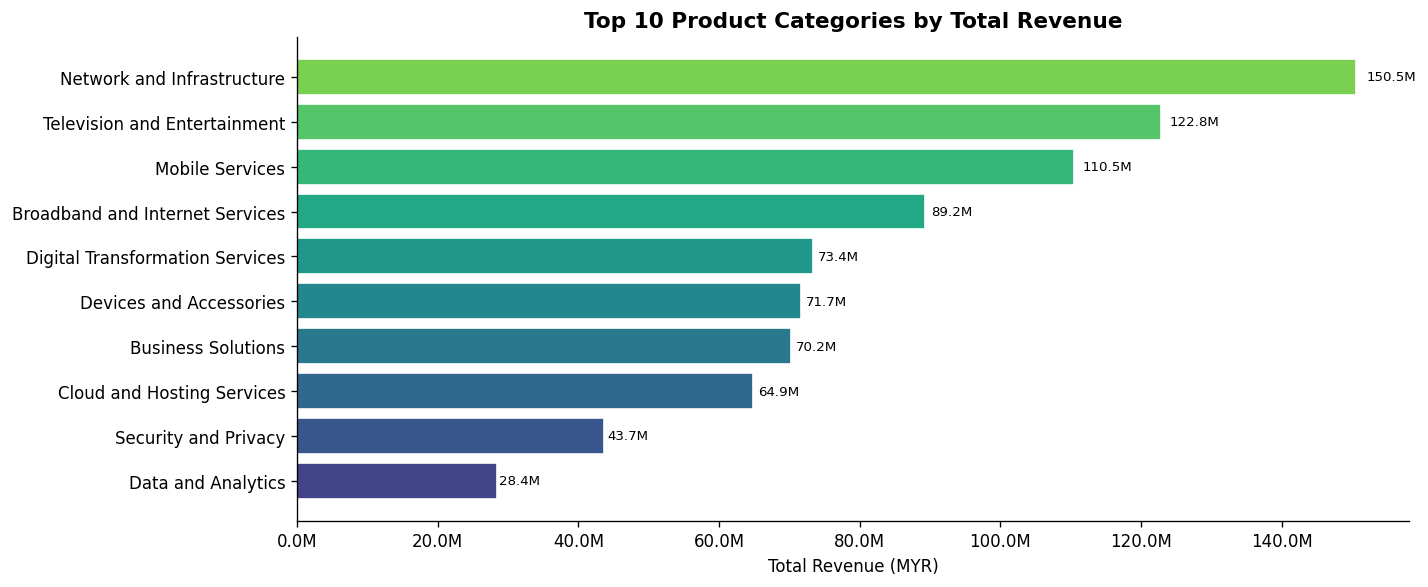

In [13]:
# ── 3.3  Top product categories ─────────────────────────────────
top_cats = df.groupby('Category', observed=True)['GrossTurnover'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_cats.index[::-1], top_cats.values[::-1],
               color=plt.cm.viridis(np.linspace(0.2, 0.8, 10)), edgecolor='white')
ax.set_title('Top 10 Product Categories by Total Revenue', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Revenue (MYR)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar in bars:
    width = bar.get_width()
    ax.text(width * 1.01, bar.get_y() + bar.get_height()/2,
            f'{width/1e6:.1f}M', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('top_categories.png', bbox_inches='tight')
plt.show()

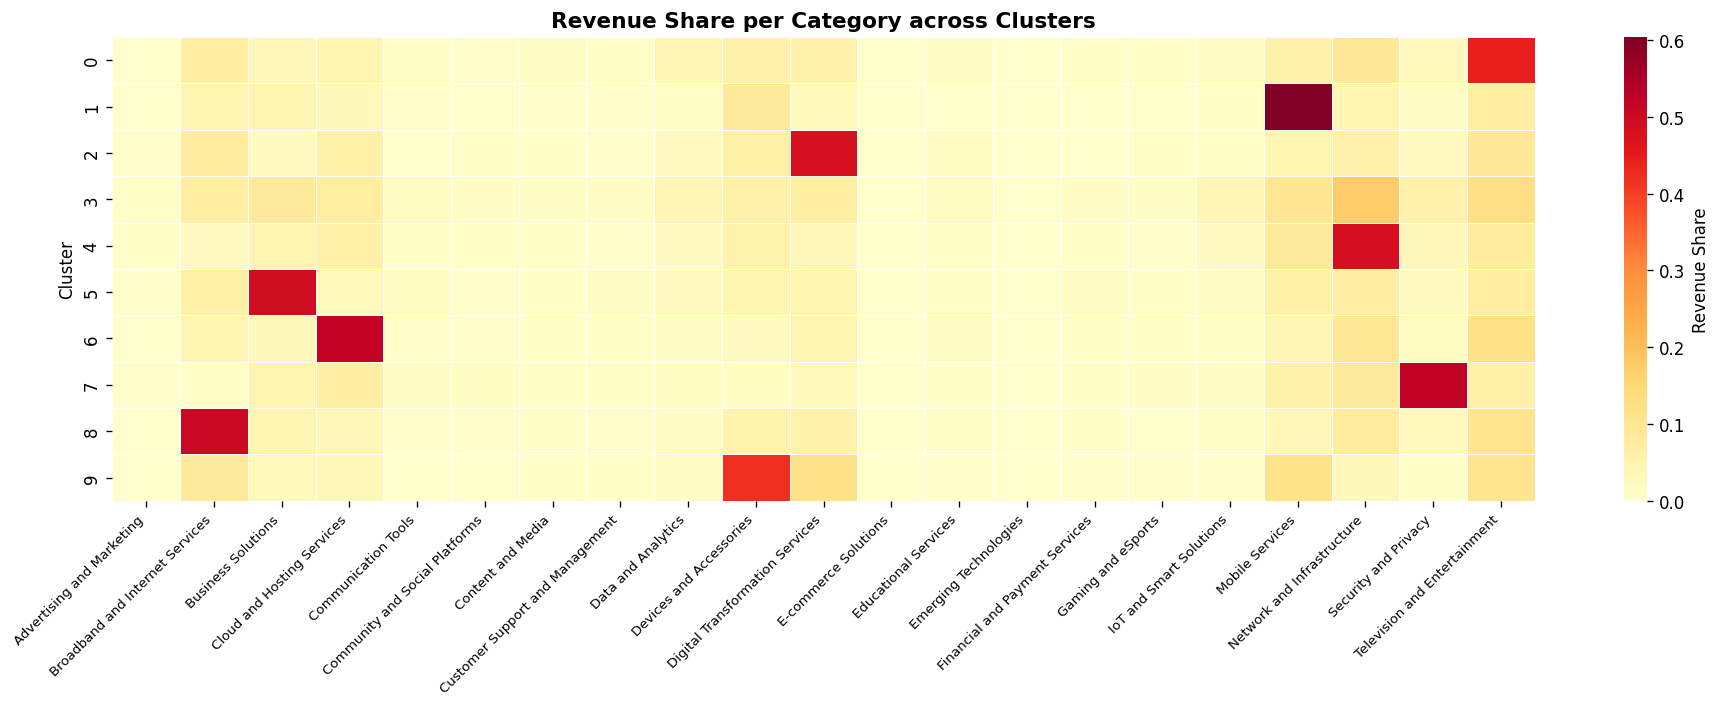

In [14]:
# ── 3.4  Cluster × Category Revenue Heatmap ─────────────────────
pivot = df.groupby(['Cluster', 'Category'], observed=True)['GrossTurnover'].sum().unstack(fill_value=0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)  # row-normalise to %

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_norm, annot=False, fmt='.1%', cmap='YlOrRd',
            linewidths=0.4, linecolor='white', ax=ax, cbar_kws={'label': 'Revenue Share'})
ax.set_title('Revenue Share per Category across Clusters', fontsize=13, fontweight='bold')
ax.set_ylabel('Cluster'); ax.set_xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('cluster_category_heatmap.png', bbox_inches='tight')
plt.show()

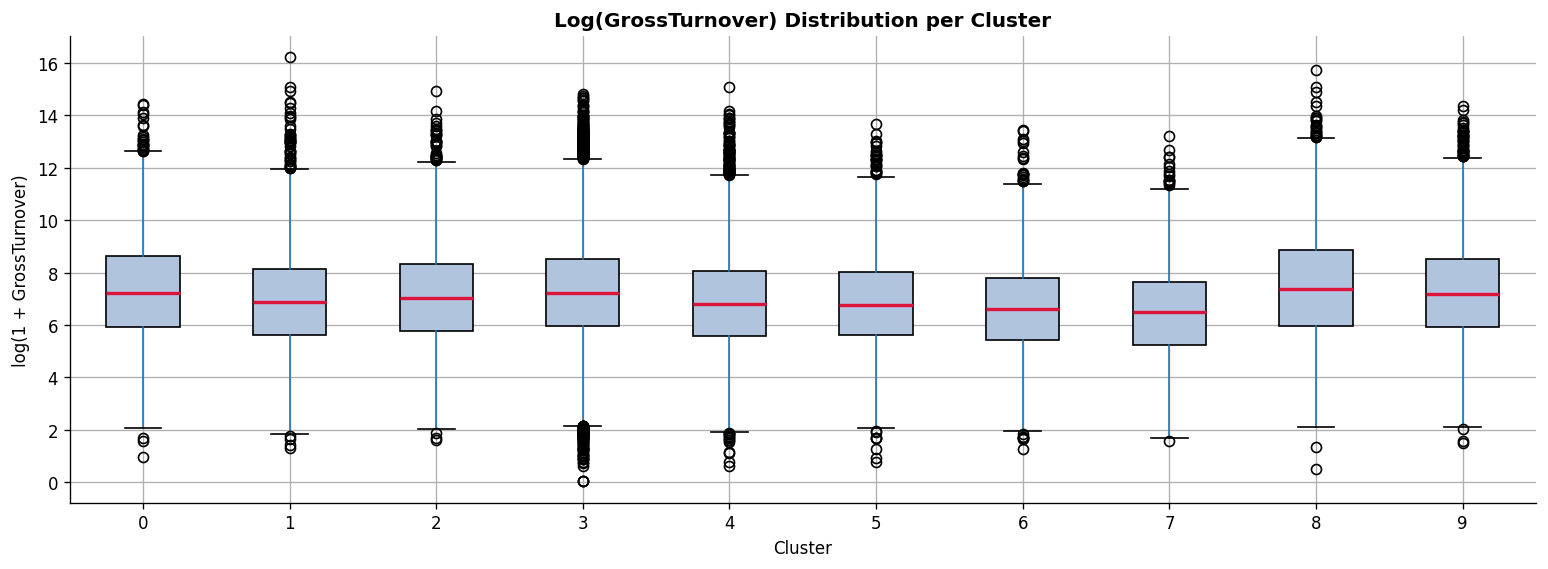

In [15]:
# ── 3.5  Turnover boxplot per cluster (log-scale) ────────────────
nonzero_df = df[df['GrossTurnover'] > 0].copy()
nonzero_df['LogTurnover'] = np.log1p(nonzero_df['GrossTurnover'])

fig, ax = plt.subplots(figsize=(13, 5))
nonzero_df.boxplot(column='LogTurnover', by='Cluster', ax=ax,
                   patch_artist=True,
                   boxprops=dict(facecolor='lightsteelblue'),
                   medianprops=dict(color='crimson', linewidth=2))
ax.set_title('Log(GrossTurnover) Distribution per Cluster', fontweight='bold')
plt.suptitle('')
ax.set_xlabel('Cluster'); ax.set_ylabel('log(1 + GrossTurnover)')
plt.tight_layout()
plt.savefig('turnover_boxplot.png', bbox_inches='tight')
plt.show()

---
## 4️⃣ Feature Engineering

In [16]:
# ── 4.1  Aggregate to customer (account) level ───────────────────
# Each row = one transaction line; we roll up to one row per account.

agg = df.groupby('Account').agg(
    TotalRevenue    = ('GrossTurnover', 'sum'),
    TotalInvoices   = ('InvoiceCount',  'sum'),
    TransactionRows = ('GrossTurnover', 'count'),
    AvgInvoiceValue = ('GrossTurnover', 'mean'),
    MaxInvoice      = ('GrossTurnover', 'max'),
    UniqueCategories= ('Category',      'nunique'),
    UniqueSubCats   = ('SubCategory',   'nunique'),
    ZeroRevTxns     = ('IsZeroRevenue', 'sum'),
    Cluster         = ('Cluster', lambda x: x.mode()[0])   # majority cluster per account
).reset_index()

# Revenue per invoice
agg['RevenuePerInvoice']  = agg['TotalRevenue'] / (agg['TotalInvoices'] + 1)
# Zero revenue ratio
agg['ZeroRevRatio']       = agg['ZeroRevTxns'] / agg['TransactionRows']
# Category diversity (normalised)
agg['CatDiversity']       = agg['UniqueCategories'] / agg['UniqueCategories'].max()
# Log transforms for skewed numerics
agg['LogTotalRevenue']    = np.log1p(agg['TotalRevenue'])
agg['LogTotalInvoices']   = np.log1p(agg['TotalInvoices'])
agg['LogAvgInvoice']      = np.log1p(agg['AvgInvoiceValue'])

print('Customer-level dataset shape:', agg.shape)
agg.head()

Customer-level dataset shape: (3438, 16)


,Account,TotalRevenue,TotalInvoices,TransactionRows,AvgInvoiceValue,MaxInvoice,UniqueCategories,UniqueSubCats,ZeroRevTxns,Cluster,RevenuePerInvoice,ZeroRevRatio,CatDiversity,LogTotalRevenue,LogTotalInvoices,LogAvgInvoice
0,100015_Customer Group_2149,21294.0580,25,219,97.233142,9250.0397,21,219,208,8,819.002231,0.949772,1.0,9.966230,3.258097,4.587344
1,100022_Customer Group_1631,22896.0566,42,219,104.548204,7651.0986,21,219,198,7,532.466433,0.904110,1.0,10.038764,3.761200,4.659168
2,100027_Customer Group_2392,48166.0658,20,219,219.936374,15516.8424,21,219,209,1,2293.622181,0.954338,1.0,10.782431,3.044522,5.397875
3,100040_Customer Group_2150,35054.3370,11,219,160.065466,28966.0000,21,219,210,4,2921.194750,0.958904,1.0,10.464683,2.484907,5.081811
4,100041_Customer Group_477,294704.4619,192,219,1345.682474,52082.0341,21,219,165,3,1526.966124,0.753425,1.0,12.593732,5.262690,7.205399


In [17]:
# ── 4.2  Top category per account (one-hot encoded) ──────────────
top_cat = (
    df.groupby(['Account', 'Category'], observed=True)['GrossTurnover']
    .sum()
    .reset_index()
    .sort_values('GrossTurnover', ascending=False)
    .drop_duplicates('Account')
    .rename(columns={'Category': 'TopCategory', 'GrossTurnover': 'TopCatRevenue'})
)

agg = agg.merge(top_cat[['Account','TopCategory']], on='Account', how='left')

# Encode top category
top_cat_dummies = pd.get_dummies(agg['TopCategory'], prefix='TopCat', dtype=int)
agg = pd.concat([agg, top_cat_dummies], axis=1)
print('Shape after category dummies:', agg.shape)

Shape after category dummies: (3438, 38)


In [18]:
# ── 4.3  Encode target (Cluster) ─────────────────────────────────
le = LabelEncoder()
agg['ClusterLabel'] = le.fit_transform(agg['Cluster'].astype(str))
print('Cluster label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
print('Class distribution:')
print(agg['ClusterLabel'].value_counts().sort_index())

Cluster label mapping: {'0': np.int64(0), '1': np.int64(1), '2': np.int64(2), '3': np.int64(3), '4': np.int64(4), '5': np.int64(5), '6': np.int64(6), '7': np.int64(7), '8': np.int64(8), '9': np.int64(9)}
Class distribution:
ClusterLabel
0     248
1     270
2     153
3    1470
4     462
5     169
6     151
7     183
8     165
9     167
Name: count, dtype: int64


In [19]:
# ── 4.4  Select feature matrix ───────────────────────────────────
NUMERIC_FEATURES = [
    'LogTotalRevenue', 'LogTotalInvoices', 'LogAvgInvoice',
    'UniqueCategories', 'UniqueSubCats', 'ZeroRevRatio',
    'CatDiversity', 'RevenuePerInvoice', 'MaxInvoice'
]
DUMMY_FEATURES   = [c for c in agg.columns if c.startswith('TopCat_')]
ALL_FEATURES     = NUMERIC_FEATURES + DUMMY_FEATURES

X = agg[ALL_FEATURES].fillna(0)
y = agg['ClusterLabel']

# Scale numeric features only
scaler = StandardScaler()
X[NUMERIC_FEATURES] = scaler.fit_transform(X[NUMERIC_FEATURES])

print(f'Feature matrix: {X.shape}  |  Target classes: {y.nunique()}')

Feature matrix: (3438, 30)  |  Target classes: 10


In [20]:
# ── 4.5  Train / Test split ──────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (2578, 30)  |  Test: (860, 30)


---
## 5️⃣ Predictive Modelling — Cluster Classification

In [21]:
# ── 5.1  Define models ───────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12,
                                                  random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                         use_label_encoder=False, eval_metric='mlogloss',
                                         random_state=42, n_jobs=-1)
}

# ── 5.2  Train & evaluate ────────────────────────────────────────
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred   = model.predict(X_test)
    acc      = accuracy_score(y_test, y_pred)
    cv_score = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'test_acc':  acc,
        'cv_mean':   cv_score.mean(),
        'cv_std':    cv_score.std()
    }
    print(f'{name:25s}  Test Acc: {acc:.4f}  |  CV: {cv_score.mean():.4f} ± {cv_score.std():.4f}')

Logistic Regression        Test Acc: 0.8105  |  CV: 0.8057 ± 0.0088
Decision Tree              Test Acc: 0.7709  |  CV: 0.7618 ± 0.0053
Random Forest              Test Acc: 0.8256  |  CV: 0.8240 ± 0.0073
XGBoost                    Test Acc: 0.8372  |  CV: 0.8362 ± 0.0110


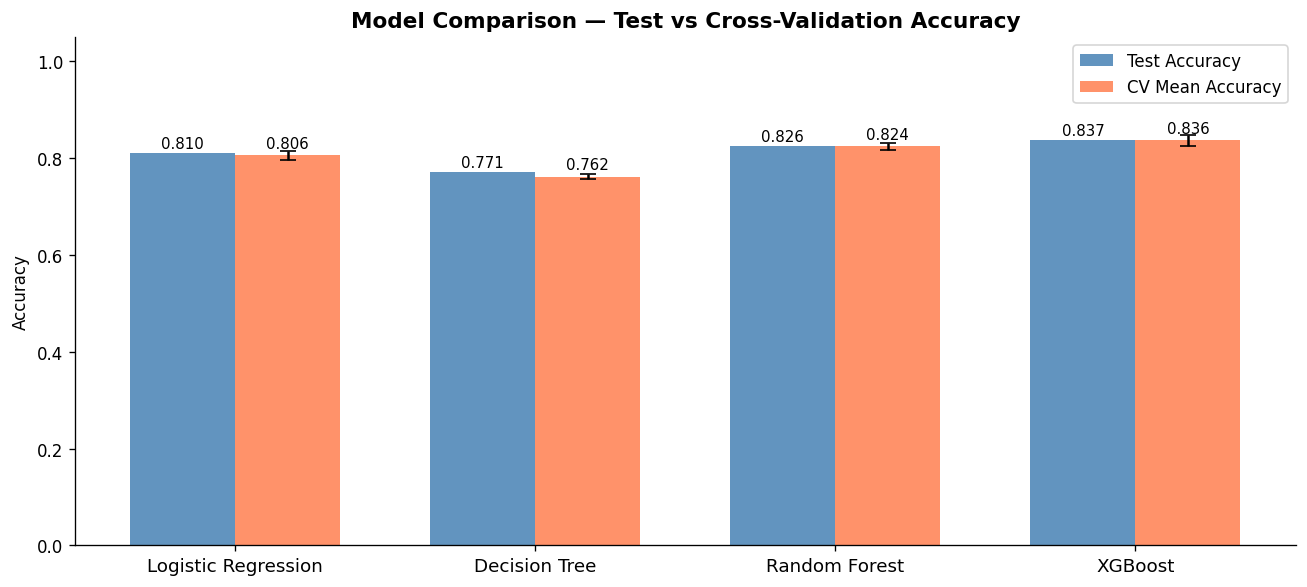

In [22]:
# ── 5.3  Model comparison chart ─────────────────────────────────
model_names = list(results.keys())
test_accs   = [results[m]['test_acc']  for m in model_names]
cv_means    = [results[m]['cv_mean']   for m in model_names]
cv_stds     = [results[m]['cv_std']    for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, test_accs, width, label='Test Accuracy',  color='steelblue',  alpha=0.85)
b2 = ax.bar(x + width/2, cv_means,  width, label='CV Mean Accuracy', color='coral', alpha=0.85,
             yerr=cv_stds, capsize=5)
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison — Test vs Cross-Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.legend()
for bar in b1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                        f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in b2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.015,
                        f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

In [23]:
# ── 5.4  Best model — detailed report ───────────────────────────
best_name  = max(results, key=lambda m: results[m]['test_acc'])
best_model = results[best_name]['model']
best_pred  = results[best_name]['y_pred']

print(f'🏆 Best Model: {best_name}  (Test Accuracy = {results[best_name]["test_acc"]:.4f})\n')
print(classification_report(y_test, best_pred,
                              target_names=[f'Cluster {c}' for c in le.classes_]))

🏆 Best Model: XGBoost  (Test Accuracy = 0.8372)

              precision    recall  f1-score   support

   Cluster 0       0.84      0.84      0.84        62
   Cluster 1       0.86      0.85      0.86        67
   Cluster 2       0.85      0.89      0.87        38
   Cluster 3       0.82      0.83      0.82       368
   Cluster 4       0.79      0.80      0.79       116
   Cluster 5       0.85      0.83      0.84        42
   Cluster 6       0.89      0.84      0.86        38
   Cluster 7       0.95      0.85      0.90        46
   Cluster 8       0.87      0.95      0.91        41
   Cluster 9       0.90      0.83      0.86        42

    accuracy                           0.84       860
   macro avg       0.86      0.85      0.86       860
weighted avg       0.84      0.84      0.84       860



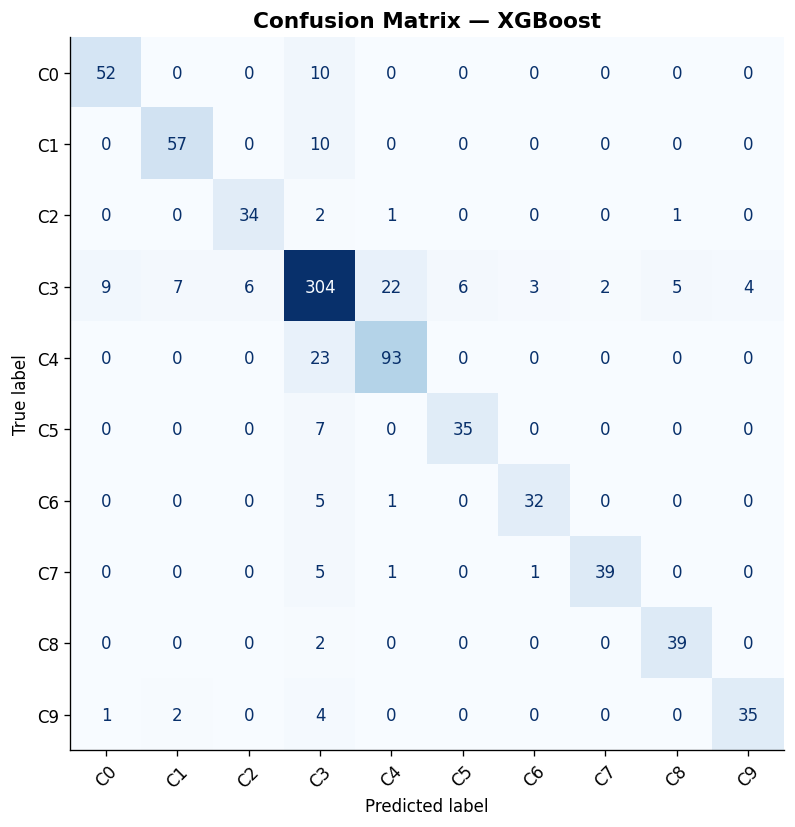

In [24]:
# ── 5.5  Confusion matrix ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=[f'C{c}' for c in le.classes_])
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

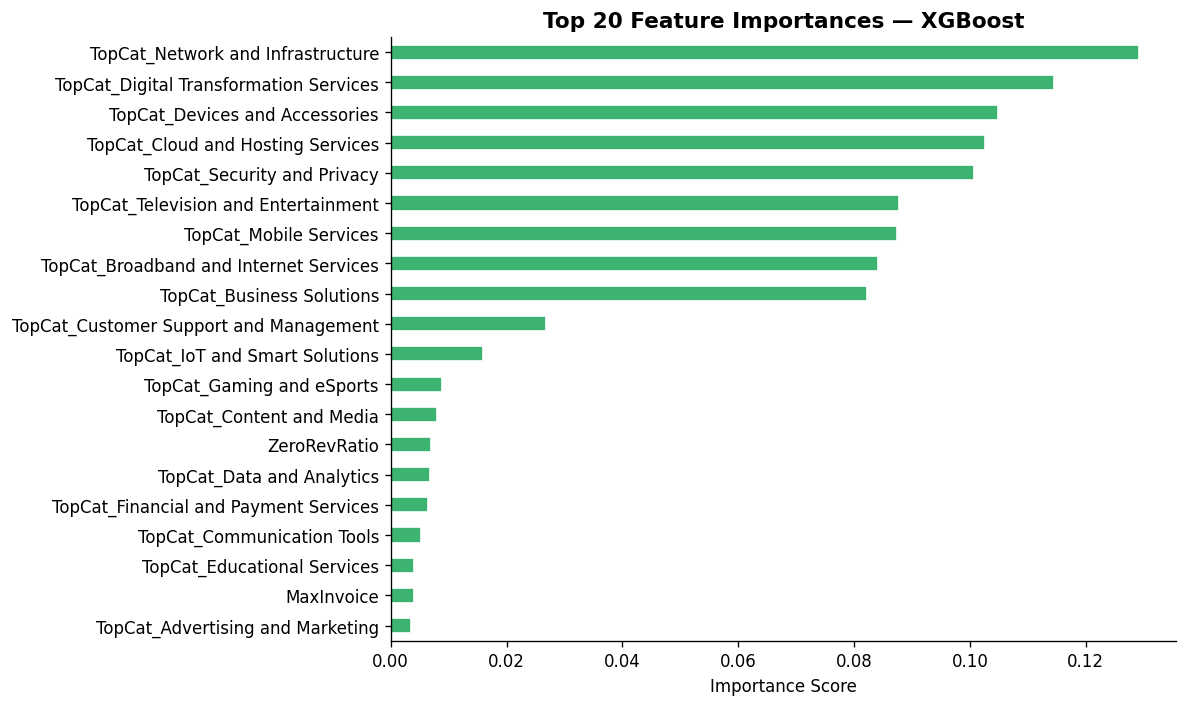

In [25]:
# ── 5.6  Feature importance (for tree-based best model) ──────────
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=ALL_FEATURES).sort_values(ascending=False)
    top20 = fi.head(20)

    fig, ax = plt.subplots(figsize=(10, 6))
    top20[::-1].plot(kind='barh', ax=ax, color='mediumseagreen', edgecolor='white')
    ax.set_title(f'Top 20 Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('feature_importance.png', bbox_inches='tight')
    plt.show()
else:
    print('Feature importance not available for this model type.')

---
## 6️⃣ Unsupervised Validation — KMeans + PCA

PCA explained variance: 69.5% in 2 components


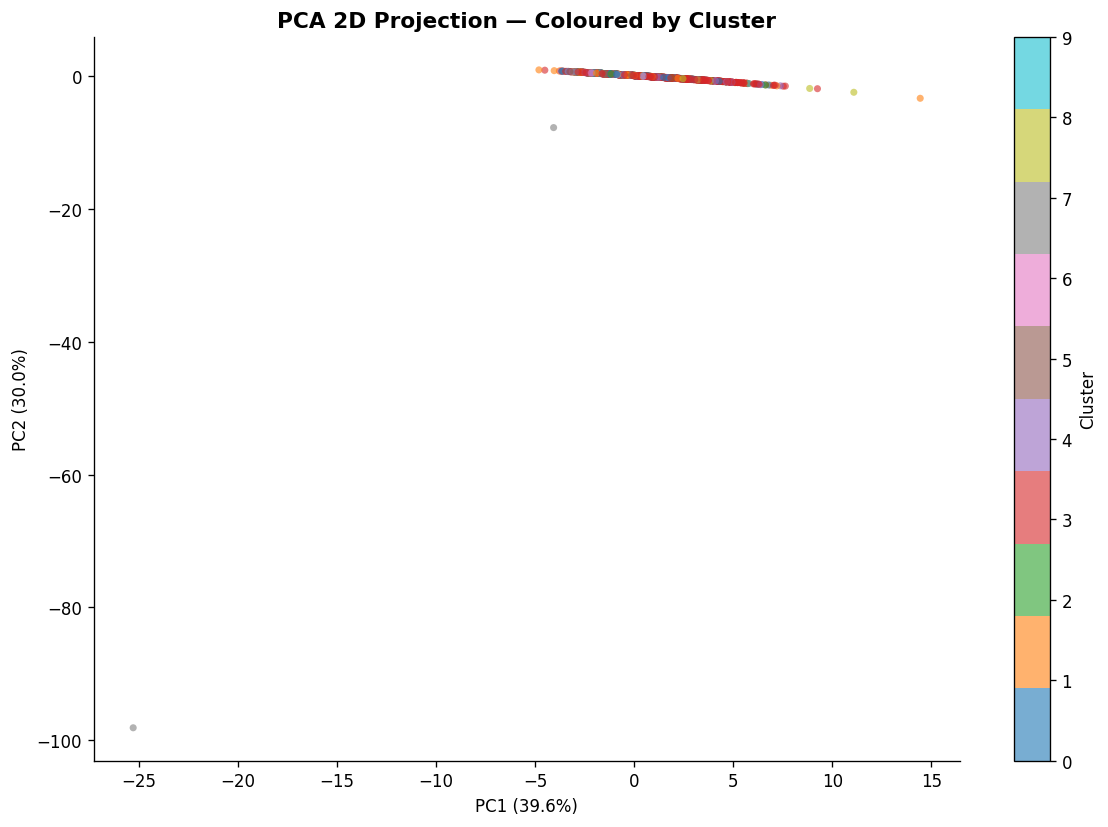

In [26]:
# ── 6.1  PCA 2-D visualisation of clusters ───────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}% in 2 components')

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=y.values, cmap='tab10', alpha=0.6, s=18, linewidths=0)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_title('PCA 2D Projection — Coloured by Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.savefig('pca_clusters.png', bbox_inches='tight')
plt.show()

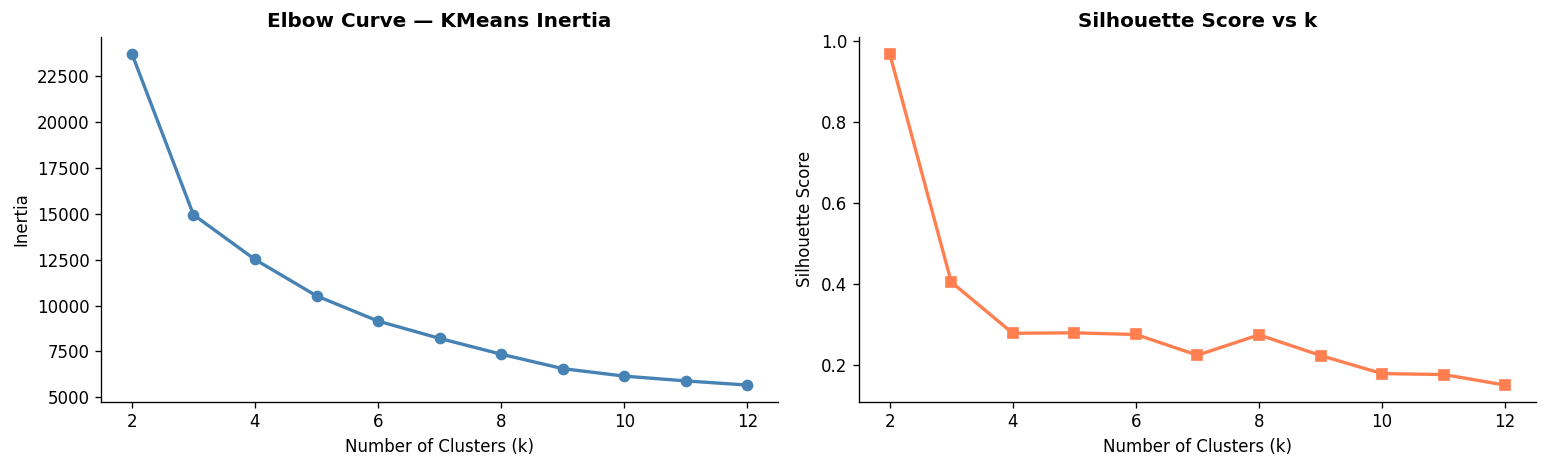

Best k by silhouette: 2  (score = 0.9691)


In [29]:
import numpy as np
# ── 6.2  Elbow method (2–12 clusters) ───────────────────────────
inertias    = []
sil_scores  = []
k_range     = range(2, 13)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)
    # Add a check to ensure KMeans produced more than one cluster
    if len(np.unique(km.labels_)) > 1:
        # Removed sample_size to avoid cases where sampling yields only one label
        sil_scores.append(silhouette_score(X, km.labels_))
    else:
        # If KMeans converged to a single cluster, silhouette score is undefined or effectively zero
        sil_scores.append(0.0) # Assign 0.0 or np.nan for an invalid clustering

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_range, inertias, 'o-', color='steelblue', lw=2)
axes[0].set_title('Elbow Curve — KMeans Inertia', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)'); axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, sil_scores, 's-', color='coral', lw=2)
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)'); axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('elbow_silhouette.png', bbox_inches='tight')
plt.show()

best_k = k_range.start + np.argmax(sil_scores)
print(f'Best k by silhouette: {best_k}  (score = {max(sil_scores):.4f})')


---
## 7️⃣ Customer Segment Profiling

In [30]:
# ── 7.1  Summary stats per cluster ──────────────────────────────
profile = agg.groupby('Cluster', observed=True).agg(
    Accounts        = ('Account',         'count'),
    TotalRevenue    = ('TotalRevenue',     'sum'),
    AvgRevenue      = ('TotalRevenue',     'mean'),
    MedianRevenue   = ('TotalRevenue',     'median'),
    AvgInvoices     = ('TotalInvoices',    'mean'),
    AvgCategories   = ('UniqueCategories', 'mean'),
    AvgZeroRatio    = ('ZeroRevRatio',     'mean')
).reset_index()

profile['RevenueShare%'] = (profile['TotalRevenue'] / profile['TotalRevenue'].sum() * 100).round(2)
profile.sort_values('TotalRevenue', ascending=False).style.format({
    'TotalRevenue': '{:,.0f}', 'AvgRevenue': '{:,.0f}',
    'MedianRevenue': '{:,.0f}', 'RevenueShare%': '{:.1f}%'
}).background_gradient(subset=['TotalRevenue'], cmap='YlOrRd')

,Cluster,Accounts,TotalRevenue,AvgRevenue,MedianRevenue,AvgInvoices,AvgCategories,AvgZeroRatio,RevenueShare%
3,3,1470,"534,880,334","363,864","70,411",246.827891,21.000000,0.821707,58.1%
4,4,462,"75,230,133","162,836","19,956",95.341991,21.000000,0.912689,8.2%
8,8,165,"73,257,418","443,984","46,464",128.345455,21.000000,0.909312,8.0%
1,1,270,"61,242,957","226,826","20,396",59.596296,21.000000,0.932251,6.7%
0,0,248,"54,412,527","219,405","29,241",94.455645,21.000000,0.920128,5.9%
9,9,167,"44,898,982","268,856","39,892",66.473054,21.000000,0.920460,4.9%
2,2,153,"35,574,373","232,512","31,479",63.986928,21.000000,0.925150,3.9%
5,5,169,"20,789,822","123,017","25,722",65.940828,21.000000,0.917484,2.3%
6,6,151,"11,995,636","79,441","20,030",48.688742,21.000000,0.933382,1.3%
7,7,183,"8,576,449","46,866","11,326",36.316940,20.885246,0.943203,0.9%


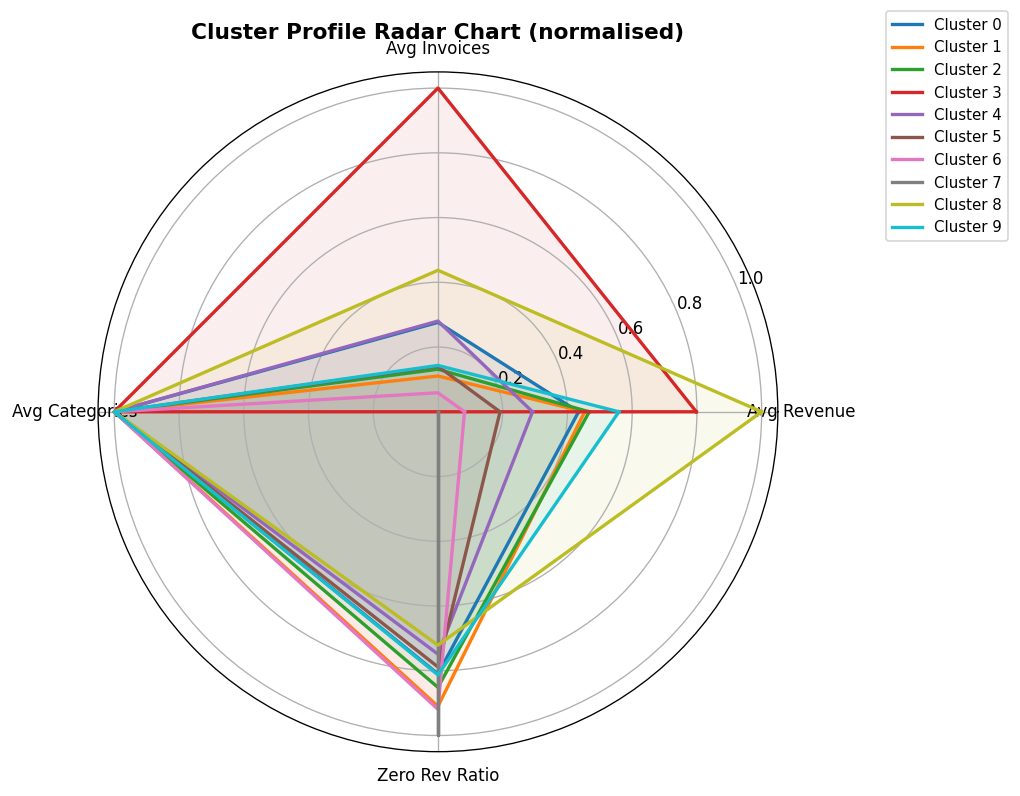

In [31]:
# ── 7.2  Radar chart — cluster profiles ─────────────────────────
radar_cols = ['AvgRevenue', 'AvgInvoices', 'AvgCategories', 'AvgZeroRatio']
radar_data = profile.set_index('Cluster')[radar_cols].copy()
# Min-max normalise per column for comparability
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

labels = radar_cols
N = len(labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, len(radar_norm)))

for i, (cluster, row) in enumerate(radar_norm.iterrows()):
    values = row.values.tolist() + row.values[:1].tolist()
    ax.plot(angles, values, color=colors[i], lw=2, label=f'Cluster {cluster}')
    ax.fill(angles, values, color=colors[i], alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(['Avg Revenue', 'Avg Invoices', 'Avg Categories', 'Zero Rev Ratio'], fontsize=10)
ax.set_title('Cluster Profile Radar Chart (normalised)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.tight_layout()
plt.savefig('radar_chart.png', bbox_inches='tight')
plt.show()

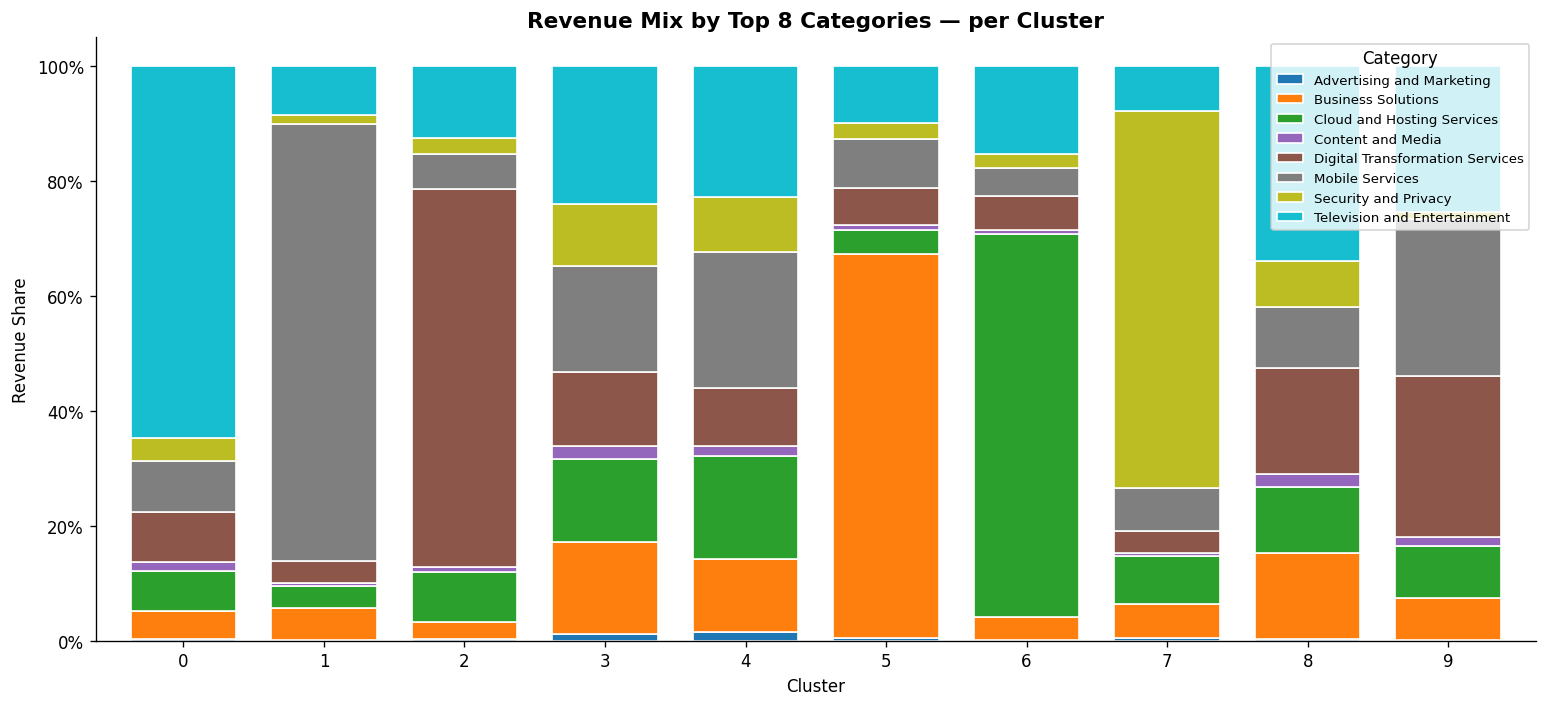

In [33]:
# ── 7.3  Stacked bar — revenue mix by cluster & category ─────────
top5_cats = df['Category'].value_counts().head(8).index.tolist()
heatmap_df = df[df['Category'].isin(top5_cats)].copy()
pivot2 = heatmap_df.groupby(['Cluster', 'Category'], observed=True)['GrossTurnover'].sum().unstack(fill_value=0)
pivot2_pct = pivot2.div(pivot2.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(13, 6))
pivot2_pct.plot(kind='bar', stacked=True, ax=ax,
                colormap='tab10', edgecolor='white', width=0.75)
ax.set_title('Revenue Mix by Top 8 Categories — per Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster'); ax.set_ylabel('Revenue Share')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc='upper right', fontsize=8, title='Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('stacked_bar_clusters.png', bbox_inches='tight')
plt.show()

---
## 8️⃣ Summary & Key Insights

In [32]:
print('=' * 65)
print('  CUSTOMER SEGMENTATION ANALYSIS — SUMMARY')
print('=' * 65)
print(f'  Raw transactions          : {df_raw.shape[0]:>10,}')
print(f'  Unique customer accounts  : {df["Account"].nunique():>10,}')
print(f'  Pre-assigned clusters     : {df["Cluster"].nunique():>10}')
print(f'  Product categories (L1)   : {df["Category"].nunique():>10}')
print(f'  Product sub-categories    : {df["SubCategory"].nunique():>10}')
print(f'  Zero-revenue transactions : {df["IsZeroRevenue"].sum():>10,}  ({df["IsZeroRevenue"].mean()*100:.0f}%)')
print()
print('  Best classification model :', best_name)
print(f'  Test accuracy             : {results[best_name]["test_acc"]*100:.2f}%')
print(f'  CV accuracy               : {results[best_name]["cv_mean"]*100:.2f}% ± {results[best_name]["cv_std"]*100:.2f}%')
print()
top_cluster = profile.loc[profile['TotalRevenue'].idxmax(), 'Cluster']
top_rev     = profile['TotalRevenue'].max()
print(f'  Highest-revenue cluster   : {top_cluster}  (MYR {top_rev:,.0f})')
print(f'  Best silhouette k         : {best_k}')
print('=' * 65)

  CUSTOMER SEGMENTATION ANALYSIS — SUMMARY
  Raw transactions          :    752,671
  Unique customer accounts  :      3,438
  Pre-assigned clusters     :         10
  Product categories (L1)   :         21
  Product sub-categories    :        219
  Zero-revenue transactions :    661,869  (88%)

  Best classification model : XGBoost
  Test accuracy             : 83.72%
  CV accuracy               : 83.62% ± 1.10%

  Highest-revenue cluster   : 3  (MYR 534,880,334)
  Best silhouette k         : 2
